In [ ]:
import sys
import os.path as op
import os
sys.path.append('/data_nfs/og86asub/netmap/netmap-evaluation/')

from netmap.src.utils.netmap_config import NetmapConfig
from src.methods.csnet.csnet_config import CsNetConfig
from src.methods.scgenerai.scgenerai_config import ScGeneRAIConfig
from src.data_simulation.data_simulation_config import DataSimulationConfig
from src.pipelines.utils import PipelineConfig
from captum.attr import GradientShap


import anndata
import numpy as np
import scanpy as sc
import pandas as pd
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment
import scipy.sparse as scs
from sklearn.cluster import SpectralClustering

from src.utils import write_config

import numpy as np
import pandas as pd
from typing import Optional
import itertools
import warnings


def downstream_recipe(adata)-> anndata.AnnData:
    """
    Downstream reciepe for an LRP anndata object:
    TODO: replace the config dict, to pass values
    """
    print(adata.shape)
    config = {'min_cells':1, 'n_neighbors': 30, 'leiden_resolution': 0.1, 'n_components': 30, 'knn_neighbors': 30}
    #sc.pp.filter_genes(adata, min_cells=1)
    #sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)
    #sc.pp.normalize_total(adata)
    #sc.pp.log1p(adata)
    print(adata.shape)
    sc.tl.pca(adata, svd_solver = 'randomized', zero_center = False)

    sc.pp.neighbors(adata, n_neighbors=config['knn_neighbors'])
    sc.tl.leiden(adata, resolution=config['leiden_resolution'])

    sc.tl.umap(adata, n_components = config['n_components'])
    return adata


def spectral_clustering(adata, n_clu = 2, key_added = 'spectral'):
    """
    Run sklearn spectral clustering on the neighbour matrix in the anndata object.

    Args:
    adata: Anndata object
    n_clu: Number of clusters to compute
    key_added: The key to add the new labelling to [Default: spectral]
    """
    sc.pp.neighbors(adata)
    ssc = SpectralClustering(n_clusters=n_clu,assign_labels='discretize',random_state=0, affinity= 'precomputed_nearest_neighbors').fit(adata.obsp['distances'])
    counter = 0
    key_added_t = key_added
    while key_added_t in adata.obs.columns:
        counter = counter + 1
        key_added_t = f'{key_added}_{counter}'
    adata.obs[key_added_t] = ssc.labels_
    adata.obs[key_added_t] = pd.Categorical(adata.obs[key_added_t])
    return adata


def unify_group_labelling(adata, grn_adata, col_adata, col_grn_adata, return_mapping=False):
    """
    Adjust group labelling such that grn_adata has the same group label than the 
    corresponding column in adata based on the grn column.

    Returns the data objects and a score of the matching as the cost of the matching
    divided by the number of cells.
    
    """
    print(adata.shape)
    print(grn_adata.shape)
    cm = contingency_matrix(adata.obs[col_adata], grn_adata.obs[col_grn_adata])
    row_ind, col_ind = linear_sum_assignment(cm, maximize = True)
    
    names_ad = np.unique(adata.obs[col_adata])
    names_grn = np.unique(grn_adata.obs[col_grn_adata])
    mapping = {}
    reverse_mapping = {}
    for i in range(len(row_ind)):
        reverse_mapping[names_grn[col_ind[i]]] = names_ad[row_ind[i]]

    col_grn_adata_remapped = col_grn_adata + '_remap'
    if isinstance(np.unique(grn_adata.obs[col_grn_adata])[0], str):
        grn_adata.obs[col_grn_adata_remapped] = [reverse_mapping[a] for a in grn_adata.obs[col_grn_adata]]
    else:
        grn_adata.obs[col_grn_adata_remapped] = [reverse_mapping[int(a)] for a in grn_adata.obs[col_grn_adata]]

    grn_adata.obs[col_grn_adata_remapped] = pd.Categorical(grn_adata.obs[col_grn_adata_remapped])

    score = cm[row_ind, col_ind].sum()/adata.obs.shape[0]
    print(adata.shape)
    print(grn_adata.shape)
    if return_mapping:
        return adata, grn_adata, score, reverse_mapping
    else:
        return adata, grn_adata, score

def compute_egde_overlaps_simple(grn_adata, net_list):
    net_recovery = {}
    for net_name, net in net_list:
        overlap_count = (pd.merge(grn_adata.var, net, on=['source', 'target'], how='inner').shape[0])
        reverse_overlap = (pd.merge(grn_adata.var, net, on=['target', 'source'], how='inner').shape[0])
        net_size = net.shape[0]
        overlap_perc = overlap_count/net_size
        reverse_overlap_perc = reverse_overlap/net_size
        net_recovery[net_name] = {'edge_overlap':overlap_count, 'net_size': net_size, 'overlap_percent':overlap_perc, 'reverse_overlap_percent': reverse_overlap_perc}

        net_recovery['total_number_edges'] = grn_adata.var.shape[0]
    return net_recovery



def process(grn_adata):
    if not scs.issparse(grn_adata.X):
        grn_adata.X[np.isnan(grn_adata.X) ] = 0
    grn_adata = downstream_recipe(grn_adata)
    n_clu = len(np.unique(grn_adata.obs['grn']))
    print(f'clustering: {n_clu} clusters')
    grn_adata = spectral_clustering(grn_adata, n_clu=n_clu)
    return grn_adata





def build_augmented_network(net):
    """
    Insert an edge between two genes if they are regulated by the same gene.
    """
    augmented_net = []
    for s in net.source.unique():
        targets = net[net.source == s].target.unique()
        cro = np.transpose([np.tile(targets, len(targets)), np.repeat(targets, len(targets))])
        augmented_net.append(cro)
    augmented_net = pd.DataFrame(np.vstack(augmented_net))
    augmented_net.columns = ['source', 'target']
    augmented_net['edge' ] = augmented_net['source']+'_'+augmented_net['target']
    return augmented_net



def get_top_edges_per_cell(grn_adata, top_edges, layer = 'X'):
    
    top_edges_data = int(np.round(grn_adata.shape[1]*top_edges))
    print(top_edges)
    partition_index = grn_adata.shape[1] - top_edges_data
    # Select the correct data based on the layer
    if layer == 'X':
        data = grn_adata.X
    else:
        data = grn_adata.layers[layer]


    # Perform the argpartition
    start = time.monotonic()
    b = np.argpartition(data, partition_index, axis=1)
    print(f'Sorting{(time.monotonic()-start)}')

    top_idx = b[:, partition_index:]
    
    start = time.monotonic()

    edge_metadata_np = np.array(grn_adata.var.loc[:, ['source', 'target']])
    top_edges_metadata = edge_metadata_np[top_idx.ravel()]

    top_edges_per_cell = pd.DataFrame(top_edges_metadata, columns=['source', 'target'])
    top_edges_per_cell['cell_barcode'] = np.repeat(grn_adata.obs.index, repeats=top_edges_data)
    top_edges_per_cell['top_edges'] = top_edges
    print(f'Pandas galore{(time.monotonic()-start)}')

    return top_edges_per_cell

def get_top_edges_global(grn_adata, top_edges: int, layer = 'X'):


    top = []

    for t in top_edges:
        top.append(get_top_edges_per_cell(grn_adata, t, layer=layer))

    top = pd.concat(top)
    return top


def get_top_edges_by_target(grn_adata, top_edges: int, layer:str):

    top = []
    for tar in np.unique(grn_adata.var.target):
        
        sub = grn_adata[:, grn_adata.var.target == tar]

        for t in top_edges:
            top.append(get_top_edges_per_cell(sub, t, layer = layer))

    top = pd.concat(top)
    return top


def get_top_edges_per_cell_per_cluster(grn_adata, nets, cluster_var = 'spectral_remap', top_edges=[100], group_by_target = False, layer='X'):
    print(f'grn_adata shape {grn_adata.shape}')
    grns = grn_adata.obs[cluster_var].unique()

    top_edges_per_cell_collector = []
    
    for i in range(len(nets)):
        for j in range(len(grns)):
            clu = grns[j]
            grn = nets[i]

            print(f"Cluster {clu} -- GRN {grn[0]}")

            grn_adata_sub = grn_adata[grn_adata.obs[cluster_var] == clu]
            

            # identify the genes with the highest mean
            if group_by_target:
                top_edges_per_cell = get_top_edges_by_target(grn_adata_sub,  top_edges, layer=layer)
            else:
                top_edges_per_cell = get_top_edges_global(grn_adata_sub,  top_edges, layer=layer)

            directions = {'forward':['source', 'target'], 'reverse':['target', 'source']}
            for diri in directions.keys():
                print(diri)
                for te in top_edges:
                    agg = top_edges_per_cell[top_edges_per_cell.top_edges==te].merge(grn[1], left_on=['source', 'target'], right_on = directions[diri]).loc[:,['cell_barcode']].groupby(['cell_barcode']).value_counts()
                    
                    agg = agg.reset_index()
                    agg.columns = ['cell_barcode', 'egde_count']
                    mean_edges_recovered = agg.loc[ :, "egde_count"].median()
                    number_of_cells = agg.shape[0]


                    agg['n_top'] = te
                    agg['net'] = grn[0]
                    # n_top, grn, TP = overlap, FP = top_k-TP
                    # Number edges 
                    n_edges = top_edges_per_cell[top_edges_per_cell.top_edges==te].shape[0]
                    TP = agg.shape[0]
                    FP = n_edges - TP
                    FN = grn[1].shape[0]-TP
                    gold_standard_edges = grn[1].shape[0]
                    current_collector =  [te, grn[0], mean_edges_recovered, number_of_cells,  gold_standard_edges, grn_adata.var.shape[0]]

                    if i == j:
                        current_collector.append('on_target')
                    else: 
                        current_collector.append('off_target')
                    
                    current_collector.append(diri)
                    top_edges_per_cell_collector.append(current_collector)


    top_edges_per_cell_collector = pd.DataFrame(top_edges_per_cell_collector)
    top_edges_per_cell_collector.columns = ['n_top', 'net', 'avg_edges_recovered', 'n_cells', 'gold_standard_edges', 'max_possible_edges', 'target', 'direction']

    return top_edges_per_cell_collector


def reformat_dataframe(recovery_rates, config_name):
        # Assuming your DataFrame is named df
    recovery_rates = recovery_rates.pivot_table(
        index=['n_top', 'net'],
        columns='type',
        values='percentage_recovered'
    ).reset_index()
    recovery_rates['method'] = config_name
    recovery_rates = recovery_rates.loc[:, ['method', 'n_top', 'on_target', 'off_target']]
    return recovery_rates




def compute_metrics(grn_ads, nets, augmented_nets, global_nets, group_key='grn', group_by_target = False, mask=False, aggregate=False):
    collect_results = {}
    results = []
    for method in grn_ads:
        print(f'Running for {method}')
        print(grn_ads[method].shape)
        collect_results[method] = compute_egde_overlaps_simple(grn_ads[method], nets)
        print(grn_ads[method].shape)
        if mask :
            #Mask the values with 0 for PCA
            grn_ads[method][~grn_ads[method].layers['mask']] = 0
        print(grn_ads[method].shape)

        grn_ads[method] = process(grn_ads[method])

        print(f'Unify group for {method}')
        print(grn_ads[method].shape)
        grn_ads[method], grn_ads[method], score = unify_group_labelling(grn_ads[method], grn_ads[method], group_key, 'spectral')
        collect_results[method]['clustering_score'] = float(score)
        print(f'Score {score}')

        if mask :
            #Now mask Mask the values with -np.inf for argsort
            grn_ads[method][~grn_ads[method].layers['mask']] = -np.inf

        if group_by_target:
            top_edges = [1,2,3,4,5,10, 15, 20, 25, 50]
        else:
            top_edges = [0.001, 0.01, 0.05, 0.1, 0.2, 0.25, 0.5, 0.75, 1.0]



        if aggregate:
            current_grn = sc.get.aggregate(grn_ads[method],by='spectral_remap', func=['mean'])
            current_grn = sc.AnnData(current_grn.layers['mean'], var = current_grn.var, obs = current_grn.obs)
        else:
            current_grn = grn_ads[method]

        for l in  ['X'] + list(current_grn.layers):
            if l in ['quantile_count', 'raw_attribution', 'raw_attribution_quantile_count', 'X']:

                top_edges_per_cell_collector = get_top_edges_per_cell_per_cluster(current_grn, nets, cluster_var = 'spectral_remap', top_edges=top_edges, group_by_target = group_by_target, layer=l)
                #top_edges_per_cell_collector_augmented = get_top_edges_per_cell_per_cluster(grn_ads[method], augmented_nets, cluster_var = 'spectral_remap', top_edges=top_edges, group_by_target = group_by_target, layer=l)
                #top_edges_per_cell_collector_global = get_top_edges_per_cell_per_cluster(grn_ads[method], global_nets, cluster_var = 'spectral_remap', top_edges=top_edges,group_by_target = group_by_target, layer=l)

                
                top_edges_per_cell_collector['method'] = method
                top_edges_per_cell_collector['net_type'] = 'strict'
                top_edges_per_cell_collector['layer'] = l
                # top_edges_per_cell_collector_augmented['method'] = method
                # top_edges_per_cell_collector_augmented['net_type'] = 'extended'
                # top_edges_per_cell_collector_augmented['layer'] = l
                # top_edges_per_cell_collector_global['method'] = method
                # top_edges_per_cell_collector_global['net_type'] = 'unspecific'
                # top_edges_per_cell_collector_global['layer'] = l


                results.append(top_edges_per_cell_collector)
                # results.append(top_edges_per_cell_collector_augmented)
                # results.append(top_edges_per_cell_collector_global)

    results = pd.concat(results)
    return results, collect_results

def parse_args():
    parser = argparse.ArgumentParser(description="Argument parser with two configuration files.")
    
    parser.add_argument(
        '--netmap_config',
        type=str,
        default='configuration.json',
        help='Path to the main configuration file (default: configuration.json)'
    )
    
    parser.add_argument(
        '--csnet_config',
        type=str,
        default='configuration.json',
        help='Path to the main configuration file (default: configuration.json)'
    )

    parser.add_argument(
        '--scgenerai_config',
        type=str,
        default='configuration.json',
        help='Path to the main configuration file (default: configuration.json)'
    )

    parser.add_argument(
        '--dataset_config',
        type=str,
        default='dataset_configuration.json',
        help='Path to the dataset configuration file (default: dataset_configuration.json)'
    )

    parser.add_argument(
        '--pipeline_config',
        type=str,
        default='dataset_configuration.json',
        help='Path to the dataset configuration file (default: dataset_configuration.json)'
    )

    parser.add_argument(
    "--config_list",  # name on the CLI - drop the `--` for positional/required parameters
    nargs="*",  # 0 or more values expected => creates a list
    type=str,
    default=None,  # default if nothing is provided
    )

    args = parser.parse_args()
    config_dict = {}
    for aa in args.config_list:
        n = aa.split('=')
        config_dict[n[0].strip()] = n[1].strip() 
    return args, config_dict

def average_edges(grn_adata, gene_names):
    """
    Creates a dictionary of binary masks for each cell and pair of genes,
    including both forward, reverse, and self-pairs (which are all zeros).

    Args:
        matrix_cells_x_genes (np.ndarray): A 2D numpy array where rows are cells
                                          and columns are genes.
        gene_list (list): A list of strings containing the names of the genes,
                          in the same order as the columns in the matrix.

    Returns:
        dict: A dictionary where keys are gene pair strings (e.g., 'GeneA_GeneB')
              and values are 1D numpy arrays representing the binary mask for that pair
              across all cells.
    """

    num_cells, num_edges = grn_adata.X.shape

    pairwise_mask_dict = {}

    gene_pairs_indices = list(itertools.combinations(gene_names, 2))
    for g1_idx, g2_idx in gene_pairs_indices:
        pairwise_mask_dict[f"{g1_idx}_{g2_idx}"] = np.mean(grn_adata[:, [f"{g1_idx}_{g2_idx}", f"{g2_idx}_{g1_idx}"]].X, axis = 1)
        # add reverse bc I am lazy
        #pairwise_mask_dict[f"{g2_idx}_{g1_idx}"] = pairwise_mask_dict[f"{g1_idx}_{g2_idx}"]
    return pairwise_mask_dict


def create_averaged_object(grn_ad):
    mean_ar = average_edges(grn_ad, gene_names=grn_ad.var.source.unique())
    column_names = mean_ar.keys()
    averaged_object = pd.DataFrame(mean_ar, columns = column_names)
    averaged_object = sc.AnnData(averaged_object, obs = grn_ad.obs)
    vars = pd.DataFrame(list(averaged_object.var.index.str.split('_', expand=False)))
    vars.columns = ['source', 'target']
    vars.index = averaged_object.var.index
    averaged_object.var = vars
    return averaged_object

def create_forward_reverse(net):
    switchnet = net.loc[:, ['target', 'source']]
    switchnet.columns = ['source', 'target']
    for_rev_net = pd.concat([net, switchnet])
    return for_rev_net


def config_reader(configs):
    config_dict = {}
    for c in configs:
        if  c.startswith('scgenerai'):
            scgenerai_config = ScGeneRAIConfig.read_yaml(configs[c])
            config_dict[c] = scgenerai_config
        elif c.startswith('csnet'):
            csnet_config = CsNetConfig.read_yaml(configs[c])
            config_dict[c] = csnet_config
        else:
            netmap_config = NetmapConfig.read_yaml(configs[c])
            config_dict[c] = netmap_config
    return config_dict




In [ ]:


config_dict = config_reader(config_dict)
dataset_config = DataSimulationConfig.read_yaml(args.dataset_config)
pipeline_config = PipelineConfig.read_yaml(args.pipeline_config)

directory_path = os.path.dirname(args.dataset_config)
config_name = os.path.basename(directory_path)

outdir = op.join(pipeline_config.summary_output_dir,config_name, dataset_config.dataset_id)
os.makedirs(outdir, exist_ok = True)

# read network files
# Augmented net contains edges between genes which are controlled by the same transcription factor
nets = [(op.basename(op.dirname(filename)), pd.read_csv(op.join(pipeline_config.clustered_network_dir, filename), sep=dataset_config.separator)) for filename in dataset_config.edgelist]
off_net = [(op.basename(op.dirname(filename)), pd.read_csv(op.join(pipeline_config.clustered_network_dir, filename), sep=dataset_config.separator)) for filename in dataset_config.common_edges]
augmented_nets = [(net[0], build_augmented_network(net[1])) for net in nets]


#Create the networks for forward and reverse nets
forward_reverse_nets = [(net[0], create_forward_reverse(net[1])) for net in nets]
forward_reverse_nets_augmented = [(net[0], build_augmented_network(net[1])) for net in forward_reverse_nets]
forward_reverse_off = [(net[0], create_forward_reverse(net[1])) for net in off_net]


grn_ads = {}
average_ads ={}
masked_ads = {}

for c in config_dict:
    try:
        print('reading file')
        if c.startswith('csnet'):
            scgenerai = sc.read_h5ad(op.join(config_dict[c].output_directory, config_dict[c].filename))
        else:
            print(f'file: {op.join(config_dict[c].output_directory, config_dict[c].adata_filename)}')
            scgenerai = sc.read_h5ad(op.join(config_dict[c].output_directory, config_dict[c].adata_filename))
            print(scgenerai.var)
        grn_ads[c] = scgenerai
        print(scgenerai.shape)
        # Create average object (forward and backward edge)
        average_ads[c] = create_averaged_object(scgenerai.copy())
                    
        print(scgenerai.shape)

        # Make a copy for the masking.
        masked_ad = scgenerai.copy()
        masked_ads[c] = masked_ad
        print(scgenerai.shape)

    except:
        continue




print('Starting computation')



overlaps_ungrouped = compute_metrics(grn_ads=grn_ads, nets= nets, augmented_nets=augmented_nets, global_nets=off_net, group_key=dataset_config.group_key, group_by_target=False, aggregate=False)
overlaps_ungrouped.to_csv(op.join(outdir, 'overlaps_global_top_k.tsv'), sep='\t')


overlaps_aggregated = compute_metrics(grn_ads=grn_ads, nets= nets, augmented_nets=augmented_nets, global_nets=off_net, group_key=dataset_config.group_key, group_by_target=False, aggregate=True)
overlaps_aggregated.to_csv(op.join(outdir, 'overlaps_global_top_k_cluster_aggregated.tsv'), sep='\t')



try:
    overlaps_masked = compute_metrics(grn_ads=masked_ads, nets= nets, augmented_nets=augmented_nets, global_nets=off_net, group_key=dataset_config.group_key, group_by_target=False, mask=True)
    overlaps_masked.to_csv(op.join(outdir, 'overlaps_global_top_k_masked.tsv'), sep='\t')
except:
    print("error")

try:
    overlaps_averaged = compute_metrics(grn_ads=average_ads, nets= forward_reverse_nets, augmented_nets=forward_reverse_nets_augmented, global_nets=forward_reverse_off, group_key=dataset_config.group_key, group_by_target=False)
    overlaps_averaged.to_csv(op.join(outdir, 'overlaps_global_top_k_averaged.tsv'), sep='\t')
except:
    print('error')



    

In [95]:
dataset_config = "/data_nfs/og86asub/netmap/netmap-evaluation/results/configurations/data_simulation/config_three/net_60_80_net_90_941_net_75_286_net_77_1396.config.yaml"
netmap_config = '/data_nfs/og86asub/netmap/netmap-evaluation/results/netmap/config_4/config_three/net_60_80_net_90_941_net_75_286_net_77_1396//config.yaml'

In [96]:
dataset_config =DataSimulationConfig.read_yaml(dataset_config)

In [97]:
config_dict = {}
config_dict['config_4'] = NetmapConfig.read_yaml(netmap_config)
c = 'config_4'
scgenerai =  sc.read_h5ad(op.join(config_dict[c].output_directory, config_dict[c].adata_filename))
ref_adata = sc.read_h5ad(config_dict[c].input_data)

{'input_data': '/data_nfs/og86asub/netmap/netmap-evaluation/data/simulated_data/config_three/net_60_80_net_90_941_net_75_286_net_77_1396/data.h5ad', 'layer': 'X', 'output_directory': '/data_nfs/og86asub/netmap/netmap-evaluation/results/netmap/config_4/config_three/net_60_80_net_90_941_net_75_286_net_77_1396', 'transcription_factors': '/data_nfs/datasets/SCENIC_DB/tf_lists/allTFs_hg38.txt', 'tf_only': False, 'penalize_error': True, 'adata_filename': 'grn_lrp.h5ad', 'grn': 'grn_lrp.tsv', 'masking_percentage': 0.1, 'print_every': 100, 'optimizer': 'Adam', 'learning_rate': 0.005, 'epochs': 10000, 'n_models': 20, 'validation_size': 0.2, 'model': 'NegativeBinomialAutoencoder', 'xai_method': 'GuidedBackprop', 'aggregation_strategy': 'mean'}


In [99]:
scgenerai.obs['grn'] = pd.Categorical(ref_adata.obs['grn'])

In [100]:
pipeline_config = PipelineConfig.read_yaml('/data_nfs/og86asub/netmap/netmap-evaluation/configurations/pipelines/pipeline_config.yaml')

In [ ]:
# read network files
# Augmented net contains edges between genes which are controlled by the same transcription factor
nets = [(op.basename(op.dirname(filename)), pd.read_csv(op.join(pipeline_config.clustered_network_dir, filename), sep=dataset_config.separator)) for filename in dataset_config.edgelist]
off_net = [(op.basename(op.dirname(filename)), pd.read_csv(op.join(pipeline_config.clustered_network_dir, filename), sep=dataset_config.separator)) for filename in dataset_config.common_edges]
augmented_nets = [(net[0], build_augmented_network(net[1])) for net in nets]


#Create the networks for forward and reverse nets
forward_reverse_nets = [(net[0], create_forward_reverse(net[1])) for net in nets]
forward_reverse_nets_augmented = [(net[0], build_augmented_network(net[1])) for net in forward_reverse_nets]
forward_reverse_off = [(net[0], create_forward_reverse(net[1])) for net in off_net]


In [106]:
grn_ads = {}
grn_ads[c] = scgenerai

In [109]:
grn_ads[c] = process(grn_ads[c])

(1500, 91204)
(1500, 91204)
clustering: 3 clusters


/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [ ]:
overlaps_ungrouped = compute_metrics(grn_ads=grn_ads, nets= nets, augmented_nets=augmented_nets, global_nets=off_net, group_key=dataset_config.group_key, group_by_target=False, aggregate=False)


In [110]:
grn_ads[c], grn_ads[c], score = unify_group_labelling(grn_ads[c], grn_ads[c], 'grn', 'spectral')


(1500, 91204)
(1500, 91204)
(1500, 91204)
(1500, 91204)


In [108]:
ref_adata = process(ref_adata)

(1500, 302)
(1500, 302)
clustering: 3 clusters


/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


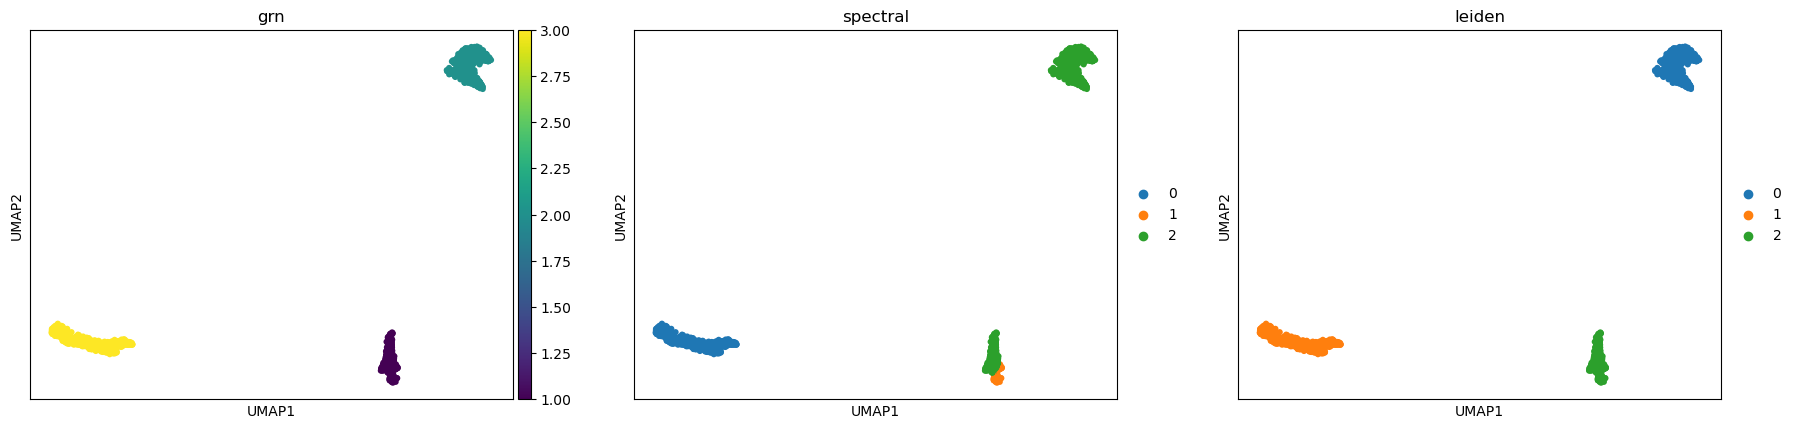

In [115]:
sc.pl.umap(ref_adata, color=['grn', 'spectral', 'leiden'])

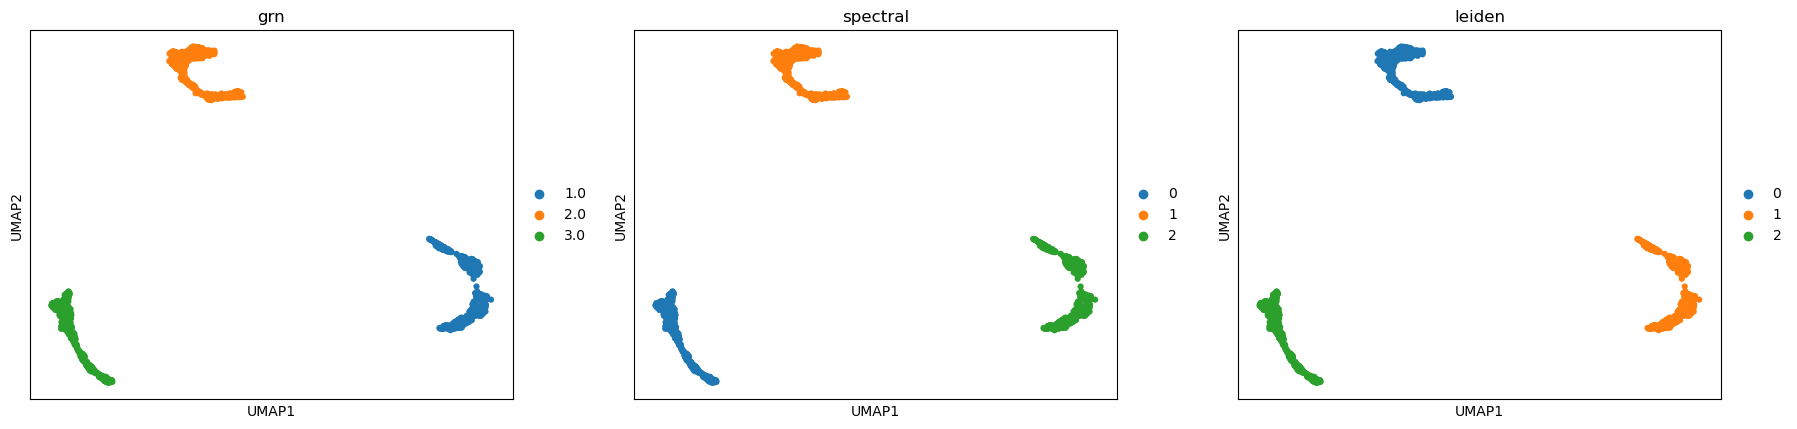

In [117]:
sc.pl.umap(grn_ads[c], color=['grn', 'spectral', 'leiden'])

In [113]:
grn_ads[c].obs['leiden']

0       3
1       3
2       3
3       3
4       3
       ..
1495    5
1496    5
1497    5
1498    5
1499    5
Name: leiden, Length: 1500, dtype: category
Categories (6, object): ['0', '1', '2', '3', '4', '5']

In [116]:
sc.tl.leiden(grn_ads[c], resolution=0.01)